# 跨度都变成两倍，为什么挠度有两种答案？

先选：4倍还是16倍？先别算，问清楚截面和荷载是否一起变。

本页HTML展示已运行的Python结果，不会在浏览器里重新执行Python。下载.ipynb，在Jupyter打开，改参数后选择“重新启动内核并运行全部”。依赖：Python 3、numpy、matplotlib、ipykernel。

## 两组试验，只比较同一输出
A组：全部长度同形放大、材料不变，荷载只取自重。B组：只增跨度，截面、材料及均布线荷载q保持不变。两组都用简支梁的小变形线弹性弯曲模型。对应C01U04—07、C04U09。

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.sans-serif":["Microsoft YaHei","SimHei","DejaVu Sans"],
                     "axes.unicode_minus":False, "figure.dpi":120})
print("Python", sys.version.split()[0], "；NumPy", np.__version__)

Python 3.13.5 ；NumPy 2.2.6


## 给基准梁定尺寸
b和h是矩形截面宽、高；q为沿跨度每米的力。此处只做教学比较，不是成桥设计参数建议。

In [2]:
#| label: parameters-scaling
L0,b0,h0=20.0,.6,1.2 # m
E=34e9 # Pa
rho,g=2500.0,9.81 # kg/m³, m/s²
lam=2.0
assert min(L0,b0,h0,E,rho,g,lam)>0
A0=b0*h0
I0=b0*h0**3/12
q0=rho*g*A0 # N/m；B组固定此基准线荷载

## 先看量之间怎样相连
$$M_{\max}=qL^2/8,\quad \sigma_{\max}=M_{\max}/W,\quad w_{\max}=5qL^4/(384EI),\quad W=bh^2/6.$$
A组有$q\propto\lambda^2,\ I\propto\lambda^4$；B组的q、I不变。两组的“跨度加倍”不是同一个实验。

In [3]:
def beam(L,b,h,q):
    A=b*h; I=b*h**3/12; W=b*h*h/6
    moment=q*L*L/8
    w=5*q*L**4/(384*E*I)
    return {"长度":L,"面积":A,"体积":A*L,"惯性矩":I,
            "总重或总载":q*L,"应力":moment/W,"挠度":w,"挠跨比":w/L}
base=beam(L0,b0,h0,q0)
similar=beam(lam*L0,lam*b0,lam*h0,q0*lam**2)
span_only=beam(lam*L0,b0,h0,q0)
print("输出         全尺寸+自重 / 基准   只加跨度+固定q / 基准")
for key in base:
    print(f"{key:8s} {similar[key]/base[key]:12.4f} {span_only[key]/base[key]:16.4f}")

输出         全尺寸+自重 / 基准   只加跨度+固定q / 基准
长度             2.0000           2.0000
面积             4.0000           1.0000
体积             8.0000           2.0000
惯性矩           16.0000           1.0000
总重或总载          8.0000           2.0000
应力             2.0000           4.0000
挠度             4.0000          16.0000
挠跨比            2.0000           8.0000


## 让跨度从1倍走到3倍
纵轴是挠度相对基准的倍数。曲线不是荷载—位移曲线，不能用它判断材料已进入非线性。

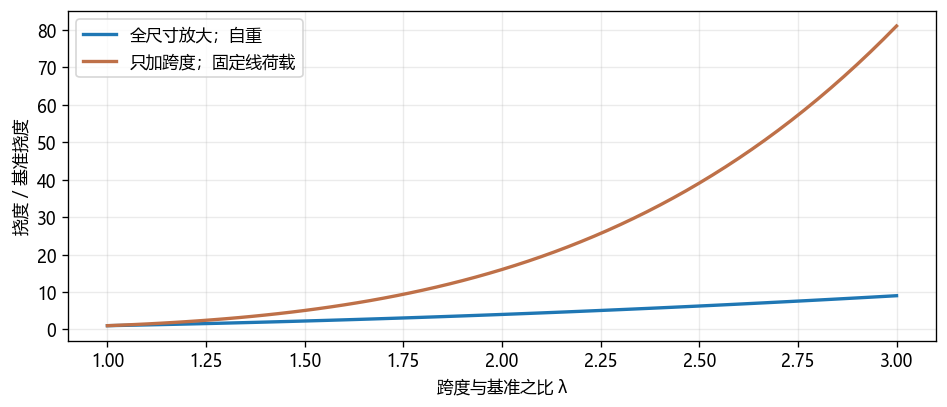

In [4]:
#| label: fig-scaling
factors=np.linspace(1,3,61)
a=[beam(t*L0,t*b0,t*h0,q0*t*t)["挠度"]/base["挠度"] for t in factors]
b=[beam(t*L0,b0,h0,q0)["挠度"]/base["挠度"] for t in factors]
fig,ax=plt.subplots(figsize=(8,3.5))
ax.plot(factors,a,label="全尺寸放大；自重",lw=2)
ax.plot(factors,b,label="只加跨度；固定线荷载",lw=2,color="#be7048")
ax.set(xlabel="跨度与基准之比 λ",ylabel="挠度 / 基准挠度")
ax.legend();ax.grid(alpha=.25);fig.tight_layout();plt.show()

## 改参数之后，保留两道已知题
下面独立检验λ=2，不随你上方选择的λ改变。

In [5]:
#| label: checks-scaling
sa=beam(2*L0,2*b0,2*h0,4*q0)
sb=beam(2*L0,b0,h0,q0)
expected={"长度":2,"面积":4,"体积":8,"惯性矩":16,"总重或总载":8,"应力":2,"挠度":4,"挠跨比":2}
for key,value in expected.items(): assert np.isclose(sa[key]/base[key],value)
assert np.isclose(sb["挠度"]/base["挠度"],16)
assert np.isclose(sb["应力"]/base["应力"],4)
print("自检通过：相似自重挠度4倍；只加跨度且q不变挠度16倍。")
print("当前A组 w/L =",f"{similar['挠跨比']:.6f}",
      "；当前B组 w/L =",f"{span_only['挠跨比']:.6f}")

自检通过：相似自重挠度4倍；只加跨度且q不变挠度16倍。
当前A组 w/L = 0.001252 ；当前B组 w/L = 0.005009


## 再解释一次
A组相似放大两倍，自重8倍、惯性矩16倍、应力2倍、挠度4倍；B组只加跨度，在q、I不变时挠度16倍。

1. 若保持总集中力不变，能不能继续用自重那列？
2. 如果w/L越来越大，是否还应无条件信任小变形计算？
3. 这些尺度幂律与混凝土开裂导致的荷载响应非线性有什么不同？